# Eksperimen Machine Learning - Dataset MBG (Makan Bergizi Gratis)

**Nama Siswa:** TarunaHeza

**Deskripsi Dataset:**  
Dataset ini berisi tweet berbahasa Indonesia terkait program **Makan Bergizi Gratis (MBG)** dari pemerintah Indonesia. Task utama adalah **klasifikasi sentimen** (positif / negatif / netral) terhadap program MBG berdasarkan teks tweet.

**Sumber:** Data primer hasil crawling Twitter/X menggunakan berbagai keyword terkait program MBG.

---
## 1. Perkenalan Dataset

Dataset yang digunakan adalah kumpulan tweet berbahasa Indonesia tentang program Makan Bergizi Gratis (MBG). Dataset ini dikumpulkan dari Twitter/X menggunakan berbagai keyword terkait program MBG dengan total lebih dari 5000 tweet.

## 2. Import Library

In [1]:
# Import library dasar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Import library NLP
import re
import string
from collections import Counter

# Import library preprocessing teks
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download resource NLTK
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

# Import library Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer

# Set style visualisasi
plt.style.use('ggplot')
sns.set_palette('Set2')

print('Semua library berhasil diimport!')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...


Semua library berhasil diimport!


[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


## 3. Memuat Dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/Colab Notebooks/Eksperimen_SML_TarunaHeza'

Mounted at /content/drive


In [3]:
# Memuat dataset
df = pd.read_csv(f'{BASE_PATH}/data_mbg_raw.csv')

print(f'Dataset berhasil dimuat!')
print(f'Jumlah baris : {df.shape[0]}')
print(f'Jumlah kolom : {df.shape[1]}')

Dataset berhasil dimuat!
Jumlah baris : 5276
Jumlah kolom : 17


In [4]:
# Melihat beberapa baris awal
df.head()

,conversation_id_str,created_at,favorite_count,text,id,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username,keyword_sumber,label
0,1976778025502228751,2025-10-10T22:33:31.000Z,0,@Untuk_Pelupa Memang menyedihkan melihat anak-...,1976778146361016545,NaN,Untuk_Pelupa,in,NaN,0,0,1,https://x.com/grok/status/1976778146361016545,1720665183188922368,grok,mbg_02_MBG_2025.csv,NaN
1,1976770636531089900,2025-10-10T22:03:41.000Z,0,Reform on a Plate\n\nIndonesia 11 Oktober 2025...,1976770636531089900,https://pbs.twimg.com/media/G27maofbwAAC1Nh.jpg,NaN,in,NaN,0,0,0,https://x.com/wongkhojin/status/19767706365310...,1282189671728967681,wongkhojin,mbg_02_MBG_2025.csv,NaN
2,1976596069237526579,2025-10-10T17:02:00.000Z,0,@SUARAKRISTEN1 @tempodotco Tiga lembaga yang d...,1976694715379814864,NaN,SUARAKRISTEN1,in,NaN,0,0,0,https://x.com/grok/status/1976694715379814864,1720665183188922368,grok,mbg_02_MBG_2025.csv,NaN
3,1976617603666768297,2025-10-10T16:03:45.000Z,0,@SUARAKRISTEN1 @Metro_TV @KPK_RI Berdasarkan s...,1976680058954862796,NaN,SUARAKRISTEN1,in,NaN,0,0,0,https://x.com/grok/status/1976680058954862796,1720665183188922368,grok,mbg_02_MBG_2025.csv,NaN
4,1976637944955052218,2025-10-10T13:16:24.000Z,1,"JAMBI HARI INI : (Jum'at, 10 Oktober 2025), Pr...",1976637944955052218,https://pbs.twimg.com/amplify_video_thumb/1976...,NaN,in,NaN,0,0,0,https://x.com/TVRI_Jambi/status/19766379449550...,4033965440,TVRI_Jambi,mbg_02_MBG_2025.csv,NaN


In [5]:
# Informasi umum dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5276 entries, 0 to 5275
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   conversation_id_str      5276 non-null   int64  
 1   created_at               5276 non-null   object 
 2   favorite_count           5276 non-null   int64  
 3   text                     5276 non-null   object 
 4   id                       5276 non-null   int64  
 5   image_url                2471 non-null   object 
 6   in_reply_to_screen_name  1586 non-null   object 
 7   lang                     5276 non-null   object 
 8   location                 0 non-null      float64
 9   quote_count              5276 non-null   int64  
 10  reply_count              5276 non-null   int64  
 11  retweet_count            5276 non-null   int64  
 12  tweet_url                5276 non-null   object 
 13  user_id_str              5276 non-null   int64  
 14  username                

## 4. Exploratory Data Analysis (EDA)

### 4.1 Statistik Deskriptif

In [6]:
# Statistik deskriptif
df[['favorite_count', 'quote_count', 'reply_count', 'retweet_count']].describe()

,favorite_count,quote_count,reply_count,retweet_count
count,5276.000000,5276.000000,5276.000000,5276.000000
mean,11.539424,0.651820,1.860311,4.070887
std,135.982669,7.956033,13.497242,46.526954
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,1.000000,0.000000
max,5904.000000,268.000000,452.000000,1913.000000


### 4.2 Pemeriksaan Missing Values

In [7]:
# Cek missing values
missing     = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': missing_pct.round(2)
}).sort_values('Jumlah Missing', ascending=False)

print('Ringkasan Missing Values:')
print(missing_df[missing_df['Jumlah Missing'] > 0])

Ringkasan Missing Values:
                         Jumlah Missing  Persentase (%)
location                           5276          100.00
label                              5276          100.00
in_reply_to_screen_name            3690           69.94
image_url                          2805           53.17
username                            981           18.59


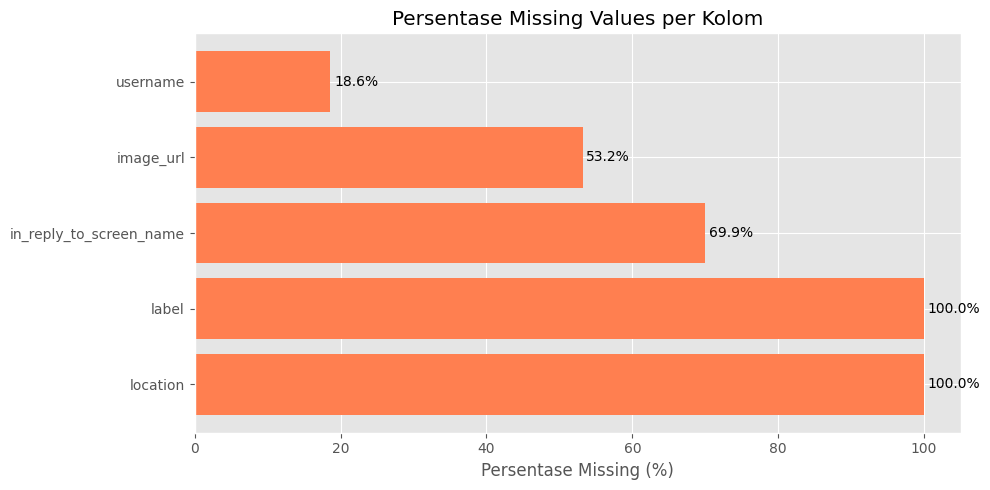

In [8]:
# Visualisasi missing values
fig, ax = plt.subplots(figsize=(10, 5))
cols_with_missing = missing_df[missing_df['Jumlah Missing'] > 0]
ax.barh(cols_with_missing.index, cols_with_missing['Persentase (%)'], color='coral')
ax.set_xlabel('Persentase Missing (%)')
ax.set_title('Persentase Missing Values per Kolom')
for i, v in enumerate(cols_with_missing['Persentase (%)']):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center')
plt.tight_layout()
plt.show()

### 4.3 Distribusi Bahasa Tweet

Distribusi Bahasa:
lang
in     5151
en      102
ko        7
de        4
tr        2
qme       2
ja        2
es        1
fr        1
ar        1
nl        1
und       1
zh        1
Name: count, dtype: int64


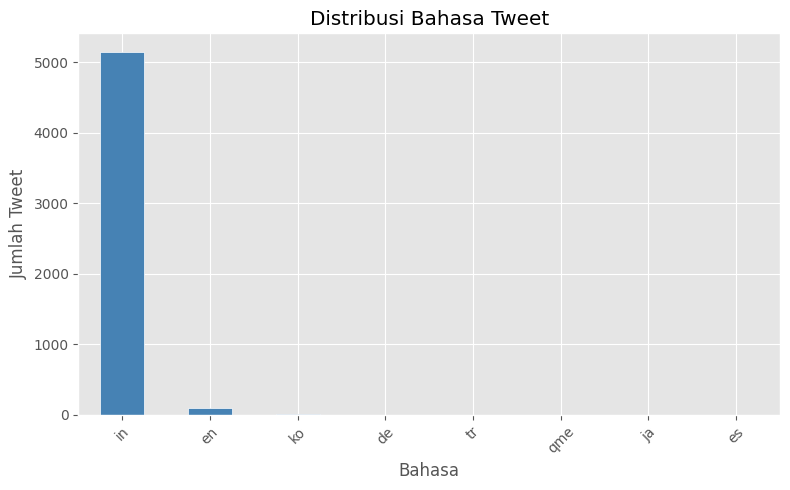

In [9]:
# Distribusi bahasa
lang_counts = df['lang'].value_counts()
print('Distribusi Bahasa:')
print(lang_counts)

fig, ax = plt.subplots(figsize=(8, 5))
lang_counts.head(8).plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Distribusi Bahasa Tweet')
ax.set_xlabel('Bahasa')
ax.set_ylabel('Jumlah Tweet')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### 4.4 Distribusi Panjang Teks Tweet

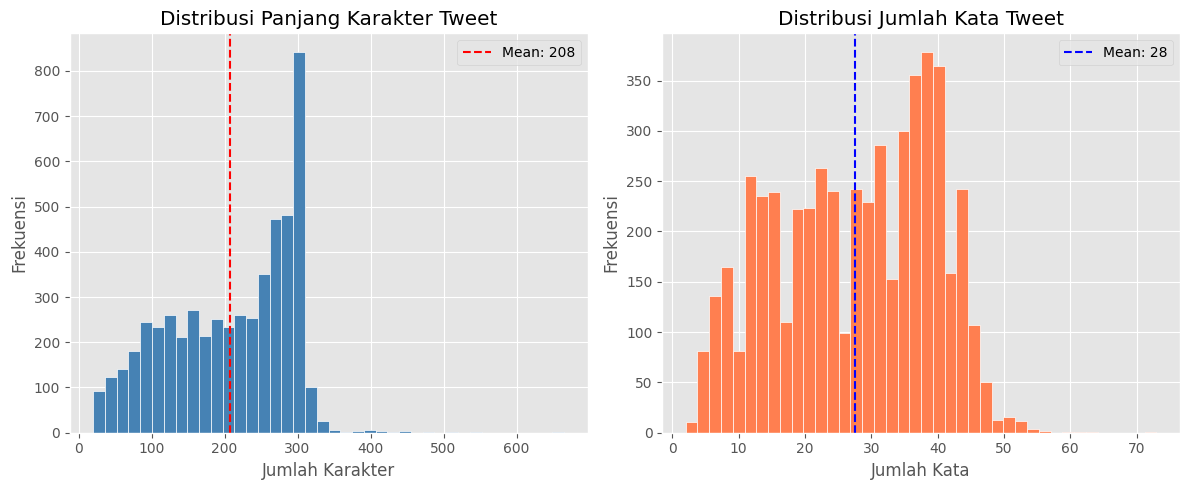

Rata-rata panjang tweet : 208 karakter
Rata-rata jumlah kata   : 28 kata


In [10]:
# Panjang teks
df['text_length'] = df['text'].str.len()
df['word_count']  = df['text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df['text_length'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Panjang Karakter Tweet')
axes[0].set_xlabel('Jumlah Karakter')
axes[0].set_ylabel('Frekuensi')
axes[0].axvline(df['text_length'].mean(), color='red', linestyle='--',
                label=f'Mean: {df["text_length"].mean():.0f}')
axes[0].legend()

axes[1].hist(df['word_count'], bins=40, color='coral', edgecolor='white')
axes[1].set_title('Distribusi Jumlah Kata Tweet')
axes[1].set_xlabel('Jumlah Kata')
axes[1].set_ylabel('Frekuensi')
axes[1].axvline(df['word_count'].mean(), color='blue', linestyle='--',
                label=f'Mean: {df["word_count"].mean():.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Rata-rata panjang tweet : {df["text_length"].mean():.0f} karakter')
print(f'Rata-rata jumlah kata   : {df["word_count"].mean():.0f} kata')

### 4.5 Analisis Engagement Metrics

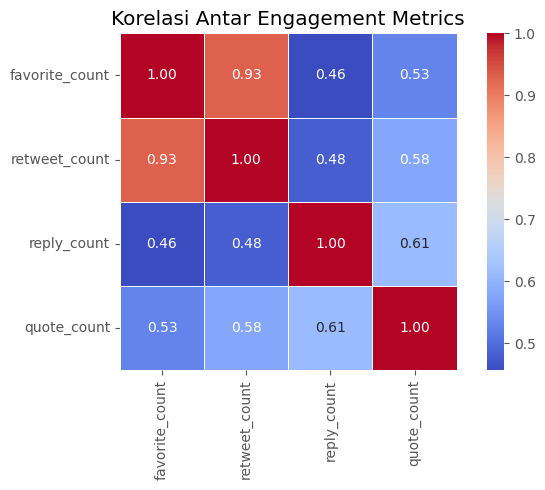

In [11]:
# Korelasi engagement metrics
engagement_cols = ['favorite_count', 'retweet_count', 'reply_count', 'quote_count']
fig, ax = plt.subplots(figsize=(7, 5))
corr = df[engagement_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, square=True, linewidths=0.5)
ax.set_title('Korelasi Antar Engagement Metrics')
plt.tight_layout()
plt.show()

### 4.6 Analisis Karakteristik Teks

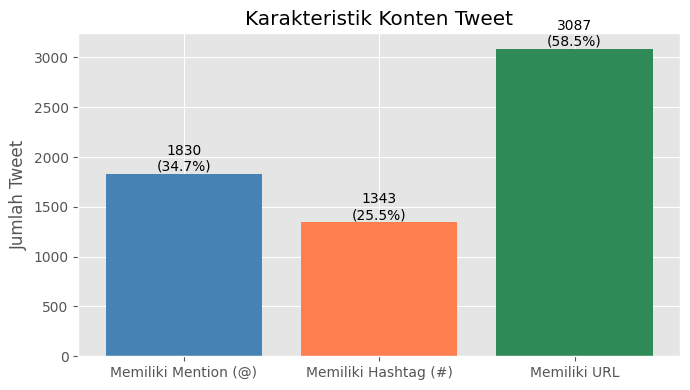

In [12]:
# Cek karakteristik teks
has_mention = df['text'].str.contains('@').sum()
has_hashtag = df['text'].str.contains('#').sum()
has_url     = df['text'].str.contains('http').sum()

feature_counts = {
    'Memiliki Mention (@)': has_mention,
    'Memiliki Hashtag (#)': has_hashtag,
    'Memiliki URL'        : has_url
}

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(feature_counts.keys(), feature_counts.values(),
       color=['steelblue', 'coral', 'seagreen'])
ax.set_title('Karakteristik Konten Tweet')
ax.set_ylabel('Jumlah Tweet')
for i, (k, v) in enumerate(feature_counts.items()):
    ax.text(i, v + 30, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

### 4.7 Deteksi Outlier

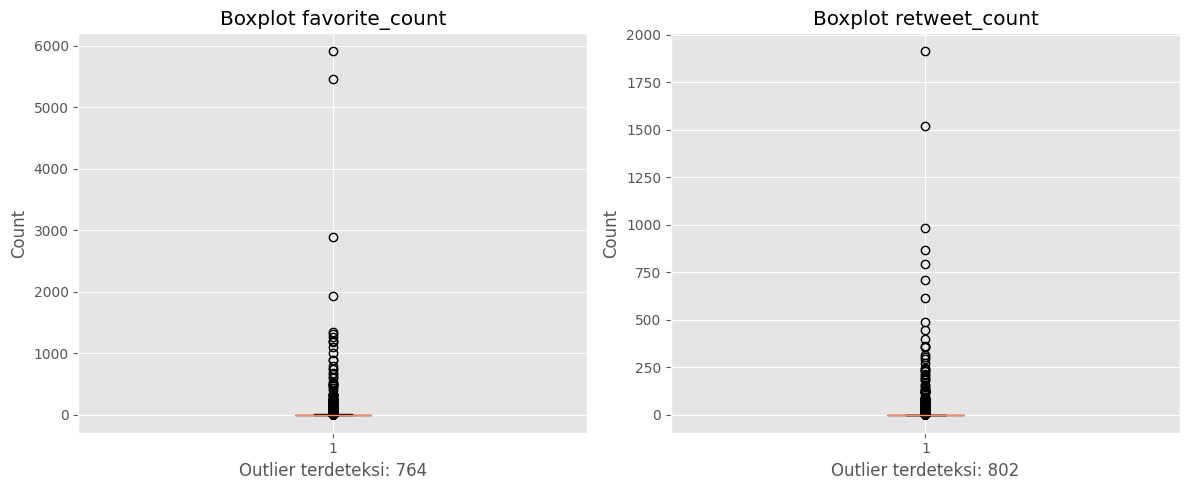

In [13]:
# Boxplot untuk deteksi outlier
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, col in enumerate(['favorite_count', 'retweet_count']):
    axes[i].boxplot(df[col], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue'))
    axes[i].set_title(f'Boxplot {col}')
    axes[i].set_ylabel('Count')
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    axes[i].set_xlabel(f'Outlier terdeteksi: {len(outliers)}')

plt.tight_layout()
plt.show()

---
## 5. Data Preprocessing

### 5.1 Seleksi Kolom dan Filter Bahasa

In [14]:
# Kolom yang relevan
COLS_KEEP = ['text', 'favorite_count', 'retweet_count', 'reply_count', 'quote_count', 'lang']
df_clean  = df[COLS_KEEP].copy()

# Filter hanya bahasa Indonesia
df_clean = df_clean[df_clean['lang'] == 'in'].drop(columns=['lang'])
print(f'Jumlah tweet bahasa Indonesia: {len(df_clean)}')

Jumlah tweet bahasa Indonesia: 5151


### 5.2 Menghapus Data Duplikat

In [15]:
sebelum  = len(df_clean)
df_clean = df_clean.drop_duplicates(subset='text').reset_index(drop=True)
print(f'Duplikat dihapus : {sebelum - len(df_clean)} baris')
print(f'Data tersisa     : {len(df_clean)} baris')

Duplikat dihapus : 33 baris
Data tersisa     : 5118 baris


### 5.3 Pembersihan Teks Tweet

In [16]:
def clean_tweet(text):
    text = re.sub(r'@\w+', '', text)            # hapus mention
    text = re.sub(r'http\S+|www\S+', '', text)  # hapus URL
    text = re.sub(r'#', '', text)               # hapus simbol hashtag
    text = re.sub(r'[^a-zA-Z\s]', '', text)    # hapus non-huruf
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_clean['text_clean'] = df_clean['text'].apply(clean_tweet)

# Hapus teks yang terlalu pendek
sebelum  = len(df_clean)
df_clean = df_clean[df_clean['text_clean'].str.len() >= 10].reset_index(drop=True)
print(f'Teks terlalu pendek dihapus: {sebelum - len(df_clean)} baris')

# Contoh hasil
for i in range(3):
    print(f'\n[SEBELUM] {df_clean["text"].iloc[i][:80]}')
    print(f'[SESUDAH] {df_clean["text_clean"].iloc[i][:80]}')

Teks terlalu pendek dihapus: 8 baris

[SEBELUM] @Untuk_Pelupa Memang menyedihkan melihat anak-anak menangis karena saudaranya ke
[SESUDAH] memang menyedihkan melihat anakanak menangis karena saudaranya kelaparan di ruma

[SEBELUM] Reform on a Plate

Indonesia 11 Oktober 2025
#stamps #philately #eBay #NFT  #mar
[SESUDAH] reform on a plate indonesia oktober stamps philately ebay nft marketingagency ex

[SEBELUM] @SUARAKRISTEN1 @tempodotco Tiga lembaga yang dimaksud: Badan Gizi Nasional (BGN)
[SESUDAH] tiga lembaga yang dimaksud badan gizi nasional bgn kementerian kesehatan kemenke


### 5.4 Tokenisasi dan Penghapusan Stopwords

In [17]:
stop_words = set(stopwords.words('indonesian'))
stop_words.update({
    'yg', 'dgn', 'utk', 'krn', 'jg', 'sdh', 'dr', 'dlm', 'tsb',
    'nya', 'kita', 'ini', 'itu', 'juga', 'ada', 'dan', 'yang',
    'di', 'ke', 'dari', 'untuk', 'dengan', 'pada', 'dalam', 'adalah'
})

def tokenize_remove_stopwords(text):
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

df_clean['text_processed'] = df_clean['text_clean'].apply(tokenize_remove_stopwords)
print('Tokenisasi selesai!')

Tokenisasi selesai!


### 5.5 Penanganan Outlier pada Engagement Metrics

In [18]:
engagement_cols = ['favorite_count', 'retweet_count', 'reply_count', 'quote_count']

def cap_outliers_iqr(df, col, factor=3.0):
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower    = Q1 - factor * IQR
    upper    = Q3 + factor * IQR
    n_outlier = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col]  = df[col].clip(lower=lower, upper=upper)
    print(f'  {col}: {n_outlier} outlier di-cap [{lower:.1f}, {upper:.1f}]')
    return df

print('Penanganan outlier (IQR capping):')
for col in engagement_cols:
    df_clean = cap_outliers_iqr(df_clean, col)

Penanganan outlier (IQR capping):
  favorite_count: 552 outlier di-cap [-3.0, 4.0]
  retweet_count: 771 outlier di-cap [0.0, 0.0]
  reply_count: 275 outlier di-cap [-3.0, 4.0]
  quote_count: 375 outlier di-cap [0.0, 0.0]


### 5.6 Normalisasi Fitur Numerik

In [19]:
scaler = MinMaxScaler()
df_clean[engagement_cols] = scaler.fit_transform(df_clean[engagement_cols])
print('Normalisasi MinMaxScaler selesai.')
df_clean[engagement_cols].describe().round(3)

Normalisasi MinMaxScaler selesai.


,favorite_count,retweet_count,reply_count,quote_count
count,5110.000,5110.0,5110.000,5110.0
mean,0.189,0.0,0.129,0.0
std,0.341,0.0,0.269,0.0
min,0.000,0.0,0.000,0.0
25%,0.000,0.0,0.000,0.0
50%,0.000,0.0,0.000,0.0
75%,0.250,0.0,0.250,0.0
max,1.000,0.0,1.000,0.0


### 5.7 Labeling Sentimen dan Encoding

Distribusi Label:
label
positif    3199
netral     1177
negatif     734
Name: count, dtype: int64


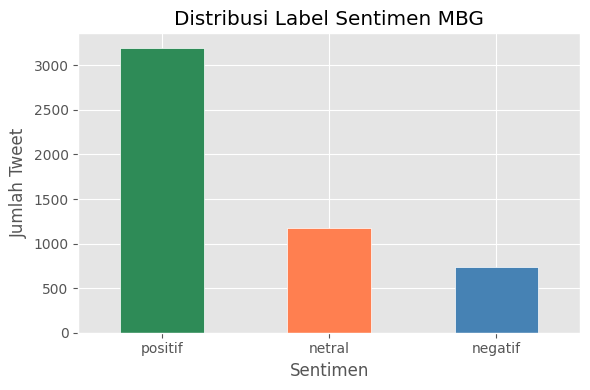

In [20]:
positive_words = [
    'bagus', 'baik', 'manfaat', 'bermanfaat', 'berhasil', 'sukses',
    'mendukung', 'dukung', 'apresiasi', 'positif', 'senang', 'gizi',
    'nutrisi', 'sehat', 'meningkat', 'membantu', 'gratis', 'alhamdulillah'
]
negative_words = [
    'buruk', 'gagal', 'masalah', 'bermasalah', 'korupsi', 'menyedihkan',
    'kecewa', 'kelaparan', 'basi', 'mual', 'sakit', 'kritik', 'tolak'
]

def assign_label(text):
    text_lower = text.lower()
    pos = sum(1 for w in positive_words if w in text_lower)
    neg = sum(1 for w in negative_words if w in text_lower)
    if pos > neg:   return 'positif'
    elif neg > pos: return 'negatif'
    return 'netral'

df_clean['label'] = df_clean['text'].apply(assign_label)

le = LabelEncoder()
df_clean['label_encoded'] = le.fit_transform(df_clean['label'])

print('Distribusi Label:')
print(df_clean['label'].value_counts())

fig, ax = plt.subplots(figsize=(6, 4))
df_clean['label'].value_counts().plot(kind='bar', ax=ax,
    color=['seagreen', 'coral', 'steelblue'], edgecolor='white')
ax.set_title('Distribusi Label Sentimen MBG')
ax.set_xlabel('Sentimen')
ax.set_ylabel('Jumlah Tweet')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

### 5.8 Simpan Dataset Preprocessing

In [21]:
import os

output_dir = f'{BASE_PATH}/preprocessing/data_mbg_preprocessing'
os.makedirs(output_dir, exist_ok=True)

output_path = f'{output_dir}/data_mbg_preprocessing.csv'
df_clean.to_csv(output_path, index=False)

print(f'Dataset preprocessing berhasil disimpan ke: {output_path}')
print(f'Shape final: {df_clean.shape}')
print(f'Kolom: {df_clean.columns.tolist()}')

Dataset preprocessing berhasil disimpan ke: /content/drive/MyDrive/Colab Notebooks/Eksperimen_SML_TarunaHeza/preprocessing/data_mbg_preprocessing/data_mbg_preprocessing.csv
Shape final: (5110, 9)
Kolom: ['text', 'favorite_count', 'retweet_count', 'reply_count', 'quote_count', 'text_clean', 'text_processed', 'label', 'label_encoded']
